## Семинар по RL для рекомендаций

Сначала посмотрим код https://github.com/BorealisAI/sasrec-ccql/tree/main

In [274]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
from typing import List
from tqdm import tqdm

%matplotlib inline

## Считаем данные соревнования от MTS по RecSys

In [275]:
df = pd.read_csv('../../interactions.csv')
df.head()

,user_id,item_id,last_watch_dt,total_dur,watched_pct
0,176549,9506,2021-05-11,4250,72.0
1,699317,1659,2021-05-29,8317,100.0
2,656683,7107,2021-05-09,10,0.0
3,864613,7638,2021-07-05,14483,100.0
4,964868,9506,2021-04-30,6725,100.0


In [276]:
df.user_id.nunique(), df.item_id.nunique()

(962179, 15706)

In [277]:
df.last_watch_dt.min(), df.last_watch_dt.max()

('2021-03-13', '2021-08-22')

In [278]:
df['last_watch_dt'] = (pd.to_datetime(df['last_watch_dt']) - pd.to_datetime(df['last_watch_dt']).min())
df['last_watch_dt'] = df.last_watch_dt.apply(lambda x: int(str(x).split()[0]))
df.sample(5)

,user_id,item_id,last_watch_dt,total_dur,watched_pct
56464,398778,10440,146,4439,10.0
310263,643893,6619,114,131,0.0
5224882,1009960,10761,117,2234,36.0
1877537,366580,1521,161,26,0.0
406340,402283,5195,155,6998,100.0


## Popular bias

<Axes: xlabel='index'>

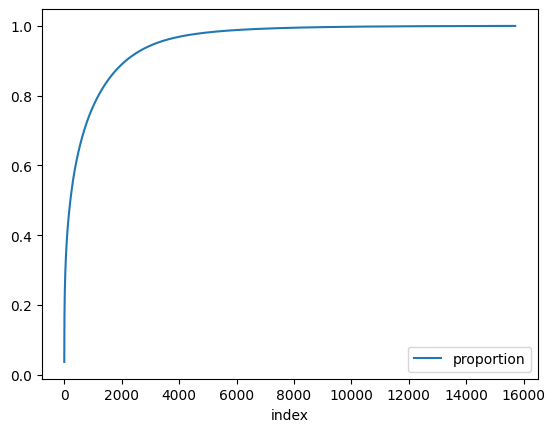

In [279]:
g = df.item_id.value_counts(True).cumsum().reset_index().reset_index()
g.plot(x='index', y='proportion')

<Axes: xlabel='index'>

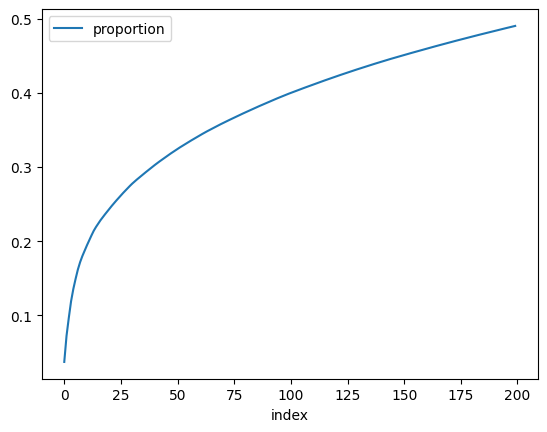

In [280]:
g = df.item_id.value_counts(True)[:200].cumsum().reset_index().reset_index()
g.plot(x='index', y='proportion')

## Популярность айтема по времени

<Axes: >

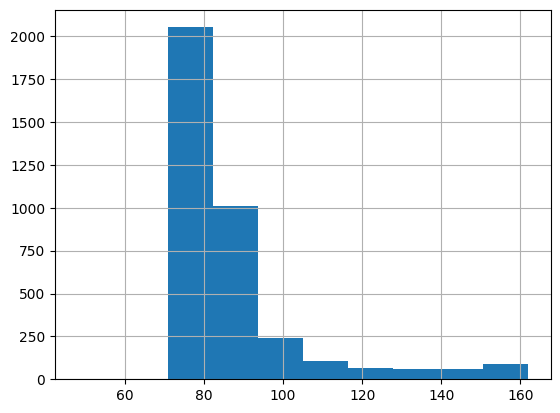

In [281]:
popular_items = df.item_id.value_counts()[:300].index.tolist()

sampled_id = np.random.choice(popular_items)

interactions = df.loc[df.item_id==sampled_id].copy()
interactions.last_watch_dt.hist()

In [282]:
temp = df.groupby('item_id').agg({'last_watch_dt':'max'}).reset_index()
temp = temp.loc[temp.item_id.isin(popular_items)].copy()
temp = temp.sort_values(by='last_watch_dt')
temp.head()

,item_id,last_watch_dt
6751,7107,87
8359,8801,140
11826,12463,141
4486,4716,141
14,14,162


<Axes: >

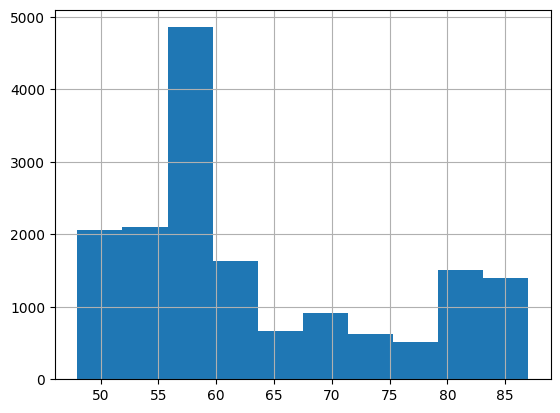

In [283]:
interactions = df.loc[df.item_id==7107].copy()
interactions.last_watch_dt.hist()

этот айтем не встретится в тесте скорее всего, хоть он и популярный

## Сделаем протокол тестирования

<Axes: >

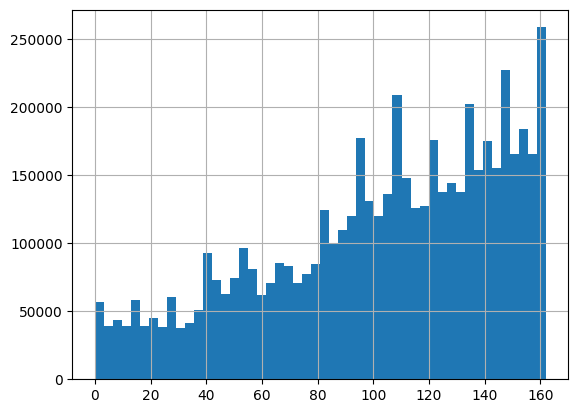

In [284]:
df.last_watch_dt.hist(bins=50)

In [285]:
train_df = df.loc[(df.last_watch_dt < 160-7)].copy()
test_df = df.loc[(df.last_watch_dt >= 160-7)].copy()

train_users = train_df.user_id.unique()
test_users = test_df.user_id.unique()

all_included = np.intersect1d(train_users, test_users)

print('число людей и там и там: ', all_included.shape[0])
print('число людей всего:', train_users.shape[0])

число людей и там и там:  134670
число людей всего: 880449


In [286]:
len(set(test_users) - set(train_users)) / len(test_users)

0.37768022181146027

## Теперь переведем к соединенному датасету все

In [287]:
n_users = 5000

all_included = np.random.choice(all_included, size=n_users, replace=False)

train_df = train_df.loc[train_df.user_id.isin(all_included)].copy()
test_df = test_df.loc[test_df.user_id.isin(all_included)].copy()

assert train_df.last_watch_dt.max() < test_df.last_watch_dt.min()
assert train_df.user_id.nunique() == n_users
assert test_df.user_id.nunique() == n_users


In [288]:
train_df.head()

,user_id,item_id,last_watch_dt,total_dur,watched_pct
20,896751,8081,65,6358,100.0
278,963902,9996,82,3268,10.0
453,964757,15815,52,4491,96.0
538,1038514,13262,115,5586,97.0
714,920674,1844,60,7725,100.0


In [289]:
train_grouped = train_df.groupby('user_id').apply(
    lambda x: [(t1, t2) for t1, t2 in sorted(zip(x.item_id, 
                                                 x.last_watch_dt), key=lambda x: x[1])]
).reset_index()
train_grouped.rename({0:'train_interactions'}, axis=1, inplace=True)

test_grouped = test_df.groupby('user_id').apply(
    lambda x: [(t1, t2) for t1, t2 in sorted(zip(x.item_id,
                                                         x.last_watch_dt), key=lambda x: x[1])]
).reset_index()
test_grouped.rename({0:'test_interactions'}, axis=1, inplace=True)

train_grouped.head()

,user_id,train_interactions
0,282,"[(5250, 45), (7626, 83), (12463, 106), (11348,..."
1,291,"[(6089, 145), (5507, 148), (10440, 148), (7019..."
2,321,"[(1844, 51), (8373, 52), (13018, 53), (8437, 5..."
3,858,"[(4140, 89), (1844, 90), (2657, 90), (5732, 90..."
4,930,"[(7417, 0), (12215, 1), (1817, 1), (4237, 9), ..."


In [290]:
joined = train_grouped.merge(test_grouped)
joined.head()

,user_id,train_interactions,test_interactions
0,282,"[(5250, 45), (7626, 83), (12463, 106), (11348,...","[(12841, 162), (8821, 162)]"
1,291,"[(6089, 145), (5507, 148), (10440, 148), (7019...","[(5576, 157)]"
2,321,"[(1844, 51), (8373, 52), (13018, 53), (8437, 5...","[(8335, 162)]"
3,858,"[(4140, 89), (1844, 90), (2657, 90), (5732, 90...","[(2766, 153), (11118, 154), (9062, 154), (1623..."
4,930,"[(7417, 0), (12215, 1), (1817, 1), (4237, 9), ...","[(12770, 153), (3542, 162)]"


In [291]:
def ndcg_metric(gt_items, predicted):
    
    at = len(predicted)
    relevance = np.array([1 if x in predicted else 0 for x in gt_items])
    # DCG uses the relevance of the recommended items
    rank_dcg = dcg(relevance)

    if rank_dcg == 0.0:
        return 0.0

    # IDCG has all relevances to 1 (or the values provided), up to the number of items in the test set that can fit in the list length
    ideal_dcg = dcg(np.sort(relevance)[::-1][:at])

    if ideal_dcg == 0.0:
        return 0.0

    ndcg_ = rank_dcg / ideal_dcg

    return ndcg_


def dcg(scores):
    return np.sum(np.divide(np.power(2, scores) - 1, np.log2(np.arange(scores.shape[0], dtype=np.float64) + 2)),
                  dtype=np.float64)


def recall_metric(gt_items, predicted):
    
    n_gt = len(gt_items)
    intersection = len(set(gt_items).intersection(set(predicted)))
    return intersection / min(n_gt, len(gt_items))



def evaluate_recommender(df, model_preds, gt_col='test_interactions', topn=10):
    
    metric_values = []
    
    for idx, row in df.iterrows():
        gt_items = [x[0] for x in row[gt_col]]
        metric_values.append((ndcg_metric(gt_items, row[model_preds]),
                              recall_metric(gt_items, row[model_preds])))
        
    return {'ndcg':np.mean([x[0] for x in metric_values]),
            'recall':np.mean([x[1] for x in metric_values])}
            


In [292]:
gt = [1, 42, 3461, 572, 234]
preds = [1]

recall_metric(gt, preds)

0.2

In [293]:
def get_metrics(df, model_preds, gt_col='test_interactions', topn=10):
    
    metric_values = []
    
    for idx, row in df.iterrows():
        gt_items = [x[0] for x in row[gt_col]]
        metric_values.append((ndcg_metric(gt_items, row[model_preds]),
                              recall_metric(gt_items, row[model_preds])))
        
    return metric_values
        

## Построим EASE

In [294]:
item2id = {k: v for v, k in enumerate(train_df.item_id.unique())}
user2id = {k:v for v, k in enumerate(train_df.user_id.unique())}

id2item = {k:v for v, k in item2id.items()}
id2user = {k:v for v, k in user2id.items()}

train_df['user_id'] = train_df.user_id.apply(lambda x: user2id[x])
train_df['item_id'] = train_df.item_id.apply(lambda x: item2id[x])

train_df.sample(5)

,user_id,item_id,last_watch_dt,total_dur,watched_pct
525790,2480,49,114,147,3.0
452947,2313,685,114,5581,72.0
766174,1941,2545,105,64,100.0
4591743,905,2042,86,3474,62.0
5219491,3216,1040,128,3117,58.0


In [295]:
from scipy import sparse as sps

matrix = sps.coo_matrix(
    (np.ones(train_df.shape[0]), (train_df['user_id'], train_df['item_id'])),
    shape=(len(user2id), len(item2id)),
)
matrix

<5000x5529 sparse matrix of type '<class 'numpy.float64'>'
	with 60713 stored elements in COOrdinate format>

In [296]:
%%time

# Обучаем конечную модель
# Мы взяли реализацию из RecBole

def fit_ease(X, reg_weight=2000):
    
    # gram matrix
    G = X.T @ X

    # add reg to diagonal
    G += reg_weight * sps.identity(G.shape[0])

    # convert to dense because inverse will be dense
    G = G.todense()

    # invert. this takes most of the time
    P = np.linalg.inv(G)
    B = P / (-np.diag(P))
    # zero out diag
    np.fill_diagonal(B, 0.)
    
    return B

w = fit_ease(matrix)

CPU times: user 21.1 s, sys: 1.09 s, total: 22.2 s
Wall time: 5.28 s


In [297]:
w.shape

(5529, 5529)

In [298]:
def get_preds(x, item2id, id2item):

    user_items = [t[0] for t in x]
    encoded = [item2id[t] for t in user_items if t in item2id]

    # Составляем вектор интеракций человека
    vector = np.zeros(len(item2id))
    vector[encoded] = 1

    vector = sps.csr_matrix(vector)

    preds = np.array(vector.dot(w))[0]#.toarray()
    preds[encoded==1] = -np.inf

    items_final = np.argsort(-preds)
    decoded = [(id2item[t], preds[t]) for t in items_final][:40]
    
    return decoded


joined['ease_preds'] = joined.train_interactions.apply(lambda x: get_preds(x, item2id, id2item))
joined.head()

,user_id,train_interactions,test_interactions,ease_preds
0,282,"[(5250, 45), (7626, 83), (12463, 106), (11348,...","[(12841, 162), (8821, 162)]","[(12173, 0.03145265198210397), (9728, 0.027101..."
1,291,"[(6089, 145), (5507, 148), (10440, 148), (7019...","[(5576, 157)]","[(15297, 0.15746125496808472), (13865, 0.14972..."
2,321,"[(1844, 51), (8373, 52), (13018, 53), (8437, 5...","[(8335, 162)]","[(9728, 0.19331649597611436), (10440, 0.180001..."
3,858,"[(4140, 89), (1844, 90), (2657, 90), (5732, 90...","[(2766, 153), (11118, 154), (9062, 154), (1623...","[(10440, 0.9586363659296706), (15297, 0.831591..."
4,930,"[(7417, 0), (12215, 1), (1817, 1), (4237, 9), ...","[(12770, 153), (3542, 162)]","[(10440, 0.4005911252521118), (15297, 0.308834..."


In [299]:
from tqdm import tqdm

new_ds = []
for row in tqdm(joined.itertuples()):
    for rec in row.ease_preds:
        new_ds.append((row.user_id, rec[0], rec[1], 1 if rec[0] in set(row.test_interactions[0]) else 0, len(row.train_interactions)))

new_ds = pd.DataFrame(new_ds, columns = ['user_id', 'item_id', 'score', 'label', 'num_intearctions'])
new_ds.label.mean()

5000it [00:00, 30411.93it/s]


0.00758

In [300]:
new_ds.label.sum()

1516

In [301]:
new_ds.sample(5)

,user_id,item_id,score,label,num_intearctions
81303,438532,12981,0.011091,0,3
138892,760678,11237,0.015480,0,6
43812,233671,11778,0.020801,0,3
120505,658856,7107,0.012219,0,2
180860,989605,13018,0.001110,0,3


In [302]:
from sklearn.metrics import roc_auc_score as auc

auc(new_ds['label'], new_ds['score'])

0.6132827847617925

скачаем признаки https://ods.ai/competitions/competition-recsys-21/data

In [303]:
users = pd.read_csv('../../users.csv')
users.head()

,user_id,age,income,sex,kids_flg
0,973171,age_25_34,income_60_90,М,1
1,962099,age_18_24,income_20_40,М,0
2,1047345,age_45_54,income_40_60,Ж,0
3,721985,age_45_54,income_20_40,Ж,0
4,704055,age_35_44,income_60_90,Ж,0


In [304]:
items = pd.read_csv('../../items.csv')
items.head()

,item_id,content_type,title,title_orig,release_year,genres,countries,for_kids,age_rating,studios,directors,actors,description,keywords
0,10711,film,Поговори с ней,Hable con ella,2002.0,"драмы, зарубежные, детективы, мелодрамы",Испания,NaN,16.0,NaN,Педро Альмодовар,"Адольфо Фернандес, Ана Фернандес, Дарио Гранди...",Мелодрама легендарного Педро Альмодовара «Пого...,"Поговори, ней, 2002, Испания, друзья, любовь, ..."
1,2508,film,Голые перцы,Search Party,2014.0,"зарубежные, приключения, комедии",США,NaN,16.0,NaN,Скот Армстронг,"Адам Палли, Брайан Хаски, Дж.Б. Смув, Джейсон ...",Уморительная современная комедия на популярную...,"Голые, перцы, 2014, США, друзья, свадьбы, прео..."
2,10716,film,Тактическая сила,Tactical Force,2011.0,"криминал, зарубежные, триллеры, боевики, комедии",Канада,NaN,16.0,NaN,Адам П. Калтраро,"Адриан Холмс, Даррен Шалави, Джерри Вассерман,...",Профессиональный рестлер Стив Остин («Все или ...,"Тактическая, сила, 2011, Канада, бандиты, ганг..."
3,7868,film,45 лет,45 Years,2015.0,"драмы, зарубежные, мелодрамы",Великобритания,NaN,16.0,NaN,Эндрю Хэй,"Александра Риддлстон-Барретт, Джеральдин Джейм...","Шарлотта Рэмплинг, Том Кортни, Джеральдин Джей...","45, лет, 2015, Великобритания, брак, жизнь, лю..."
4,16268,film,Все решает мгновение,NaN,1978.0,"драмы, спорт, советские, мелодрамы",СССР,NaN,12.0,Ленфильм,Виктор Садовский,"Александр Абдулов, Александр Демьяненко, Алекс...",Расчетливая чаровница из советского кинохита «...,"Все, решает, мгновение, 1978, СССР, сильные, ж..."


In [305]:
bdf = new_ds.merge(users).merge(items[['content_type', 'release_year','genres', 'age_rating', 'item_id']])
bdf['release_year'] = bdf['release_year'].fillna('-1').astype(int)
bdf.sample(5)

,user_id,item_id,score,label,num_intearctions,age,income,sex,kids_flg,content_type,release_year,genres,age_rating
37097,536417,15297,0.265715,0,12,age_18_24,income_20_40,Ж,0,series,2021,"драмы, мелодрамы",18.0
102088,247074,7417,0.051159,0,5,age_35_44,income_20_40,Ж,1,film,2020,комедии,16.0
112721,809964,11237,0.020848,0,7,age_25_34,income_40_60,М,0,film,2021,комедии,16.0
131709,947676,7107,0.004795,0,2,age_45_54,income_20_40,Ж,0,series,2021,"драмы, военные, приключения",12.0
126381,31541,4716,0.033716,0,14,age_25_34,income_20_40,Ж,0,series,2013,"драмы, мелодрамы",18.0


In [306]:
for cat in ['age','income','sex','content_type']:
    bdf[cat] = bdf[cat].astype("category")
    

In [307]:
from sklearn.model_selection import train_test_split

train_bdf, test_bdf = train_test_split(bdf)


In [308]:
pos = train_bdf.loc[train_bdf.label==1].copy()
neg = train_bdf.loc[train_bdf.label==0].sample(pos.shape[0] * 4)

new_train = pd.concat([pos, neg])

In [309]:
from lightgbm import LGBMClassifier, plot_importance

FEATURES = ['score', 'age','income','sex','content_type', 'release_year','num_intearctions']


fit_params={#"early_stopping_rounds": 35, 
           # "eval_metric": 'auc', 
           #"eval_set": [(test_df[FEATURES], test_df["label"])],
            #'eval_names': ['valid'],
            #'verbose': 5,
           }

clf = LGBMClassifier(max_depth=3, 
                     
                     #max_bin=30,
                     #boosting_type='dart',
                     random_state=0, 
                    # metric='None', 
                     n_estimators=100,
                     learning_rate=0.1,
                     n_jobs=10)
clf.fit(
    X=train_bdf[FEATURES],
    y=train_bdf["label"],
    **fit_params
)

[LightGBM] [Info] Number of positive: 914, number of negative: 121846
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001133 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 450
[LightGBM] [Info] Number of data points in the train set: 122760, number of used features: 7
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.007445 -> initscore=-4.892683
[LightGBM] [Info] Start training from score -4.892683
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain:

LGBMClassifier(max_depth=3, n_jobs=10, random_state=0)

In [310]:

test_bdf.age.value_counts()

age
age_25_34     12366
age_35_44     11784
age_45_54      7304
age_18_24      4249
age_55_64      2754
age_65_inf     2017
Name: count, dtype: int64

In [311]:
test_bdf['boosting_preds_new'] = clf.predict_proba(test_bdf[FEATURES])[:, 1]

In [312]:

test_bdf['boosting_preds'] = clf.predict_proba(test_bdf[FEATURES])[:, 1]

for model_name in ['score','boosting_preds','boosting_preds_new']:
    print(model_name, ": ", auc(test_bdf['label'], test_bdf[model_name])) 
    


score :  0.6039420014938695
boosting_preds :  0.7314800615516354
boosting_preds_new :  0.7314800615516354


<Axes: title={'center': 'Feature importance'}, xlabel='Feature importance', ylabel='Features'>

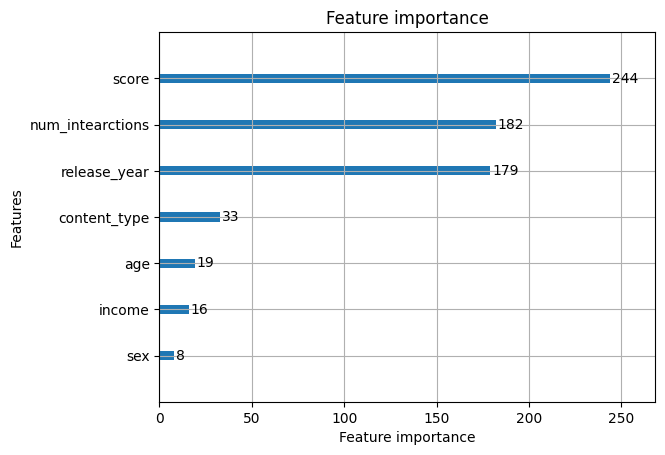

In [313]:
plot_importance(clf)

LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray


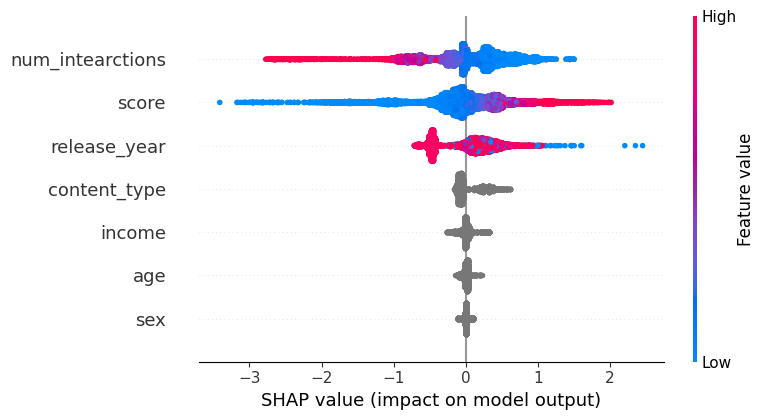

In [314]:
import shap
explainer = shap.TreeExplainer(clf)
shap_values = explainer.shap_values(test_bdf[FEATURES][:10000])
shap.summary_plot(shap_values[1], test_bdf[FEATURES][:10000])

In [315]:
from sklearn.metrics import ndcg_score

In [316]:
def get_recall(x, col, at=3):

    if x.label.sum():
        return x.sort_values(by=col, ascending=False)[:at].label.sum() / x.label.sum()
        
    return 0
    
test_bdf.groupby('user_id').apply(lambda x: get_recall(x, 'score', at=10)).mean()

0.07380254154447703

In [317]:
test_bdf.groupby('user_id').apply(lambda x: get_recall(x, 'boosting_preds', at=10)).mean()

0.0747800586510264

In [318]:
test_bdf.groupby('user_id').apply(lambda x: get_recall(x, 'boosting_preds_new', at=10)).mean()

0.0747800586510264

## Часть про многорукие бандиты

https://github.com/fidelity/mab2rec

In [319]:

#test_bdf

train_bdf.head()

,user_id,item_id,score,label,num_intearctions,age,income,sex,kids_flg,content_type,release_year,genres,age_rating
68712,964414,7829,0.069293,0,15,age_35_44,income_20_40,М,1,film,2021,"боевики, фантастика, фэнтези, приключения",16.0
27117,493296,3734,0.138965,0,38,age_35_44,income_20_40,М,0,film,2021,комедии,16.0
20339,670524,7102,0.012707,0,3,age_35_44,income_20_40,Ж,1,film,2019,"боевики, триллеры",18.0
74062,547217,4495,0.093014,0,81,age_65_inf,income_20_40,М,0,film,2020,драмы,16.0
105987,744205,10464,0.016701,0,8,NaN,NaN,М,0,film,2020,"драмы, триллеры",16.0


In [56]:
train_bdf.label.value_counts()

label
0    121234
1       896
Name: count, dtype: int64

In [328]:
# Import 
from mab2rec import BanditRecommender, LearningPolicy, NeighborhoodPolicy
from mab2rec.pipeline import train, score

# !pip3 install mab2rec

TRAIN_FEATURES = ['num_intearctions', 'score', 'release_year']

from typing import Literal, Optional
import numpy as np
from typing import Literal, Optional

def train_bandit(train_df):
    
    inters = train_bdf[['user_id','label','item_id']].copy()
    inters.rename({'label':'response'}, axis=1, inplace=True)
    

    rec =  BanditRecommender(LearningPolicy.LinGreedy(epsilon=0.01), top_k=inters.item_id.nunique())
    #rec =  BanditRecommender(LearningPolicy.LinUCB(alpha=0.1, scale=False), top_k=inters.item_id.nunique())
    
    
    #rec =  BanditRecommender(LearningPolicy.LinUCB(alpha=1, l2_lambda=10, scale=False), 
    #                         top_k=inters.item_id.nunique(), )
    #rec = BanditRecommender(LearningPolicy.UCB1(alpha=1),
    #                        NeighborhoodPolicy.TreeBandit())

    rec.fit(inters['item_id'].values, inters['response'].values, train_bdf[TRAIN_FEATURES[:]],)
    
    return rec


In [329]:
rec = train_bandit(train_bdf)

In [330]:
scores =  rec.predict_expectations(test_bdf[TRAIN_FEATURES])

In [331]:
true_scores = []

print('scores are ready')

for i, (idx, row) in tqdm(enumerate(test_bdf.iterrows()), total=test_bdf.shape[0]):
    true_scores.append(scores[i].get(row.item_id, 0))
    
test_bdf['bandit'] = true_scores

print('ready')

scores are ready


100%|████████████████████████████████████████████████████████████████████████████████████████████| 40920/40920 [00:03<00:00, 11199.05it/s]

ready


In [325]:

for model_name in ['score','boosting_preds','boosting_preds_new', 'bandit']:
    print(model_name, ": ", auc(test_bdf['label'], test_bdf[model_name])) 
    

score :  0.6039420014938695
boosting_preds :  0.7314800615516354
boosting_preds_new :  0.7314800615516354
bandit :  0.7061430270033482


In [91]:
test_bdf.loc[test_bdf.user_id==544805]

,user_id,item_id,score,label,num_intearctions,age,income,sex,kids_flg,content_type,release_year,genres,age_rating,boosting_preds_new,boosting_preds,bandit
137876,544805,11919,0.025508,0,9,age_18_24,income_40_60,М,1,film,2004,"фантастика, мультфильм, приключения",6.0,0.009288,0.009288,0.087168
140847,544805,10605,0.023930,0,9,age_18_24,income_40_60,М,1,film,2016,"мультфильм, приключения, комедии",6.0,0.006270,0.006270,0.068374
139846,544805,13159,0.025593,0,9,age_18_24,income_40_60,М,1,film,2007,"мультфильм, приключения, драмы, фэнтези, комедии",0.0,0.008455,0.008455,0.074627
57959,544805,13865,0.095561,0,9,age_18_24,income_40_60,М,1,film,2021,"драмы, военные, приключения",12.0,0.013416,0.013416,0.037225
54443,544805,7571,0.036736,0,9,age_18_24,income_40_60,М,1,film,2020,"мультфильм, приключения, семейное, фэнтези, ко...",6.0,0.003278,0.003278,0.026698
135842,544805,10214,0.017083,0,9,age_18_24,income_40_60,М,1,film,2017,"ужасы, мультфильм, фэнтези, комедии",6.0,0.006482,0.006482,0.090989
43419,544805,12192,0.029165,0,9,age_18_24,income_40_60,М,1,series,2019,"драмы, детективы, комедии",16.0,0.009491,0.009491,0.045337
20006,544805,4880,0.044119,0,9,age_18_24,income_40_60,М,1,series,2021,комедии,18.0,0.008303,0.008303,0.024960
74736,544805,3182,0.035509,0,9,age_18_24,income_40_60,М,1,film,2018,"мультфильм, приключения, фантастика, семейное,...",6.0,0.008996,0.008996,0.056765
136185,544805,5411,0.020747,0,9,age_18_24,income_40_60,М,1,film,2018,"мультфильм, фэнтези, приключения, комедии",6.0,0.006482,0.006482,0.078081


In [326]:
from sklearn.metrics.pairwise import pairwise_distances

for column in ['boosting_preds','bandit']:
    
    test_bdf['rank'] = test_bdf.sort_values(by=column).groupby('user_id')[column].rank(ascending=False, method='min')
    
    top_3 = test_bdf.loc[test_bdf['rank'] < 3].copy()
    
    
    unique_recommended_items = top_3['item_id'].nunique()
    total_possible_items = test_bdf.item_id.nunique()
    coverage = unique_recommended_items / total_possible_items
    print('column:', column, 'coverage:', coverage)



column: boosting_preds coverage: 0.3186141304347826
column: bandit coverage: 0.4470108695652174


In [327]:


for column in ['boosting_preds','bandit']:
    
    df_sorted = test_bdf.sort_values(['user_id', column], ascending=[True, False])

    # Рассчитываем NDCG для каждого пользователя
    ndcg_results = []
    for user_id, group in df_sorted.groupby('user_id'):
        true_relevance = group['label'].values  # или group['label']
        
        # Идеальный порядок (отсортированный по убыванию)
        ideal_relevance = np.sort(true_relevance)[::-1]
        
        # Рассчитываем NDCG (можно также использовать sklearn.metrics.ndcg_score)
        dcg = sum((2 ** rel - 1) / np.log2(idx + 2) for idx, rel in enumerate(true_relevance))
        idcg = sum((2 ** rel - 1) / np.log2(idx + 2) for idx, rel in enumerate(ideal_relevance))
        ndcg = dcg / idcg if idcg > 0 else 0
        
        ndcg_results.append({'user_id': user_id, 'ndcg': ndcg})
    
    ndcg_df = pd.DataFrame(ndcg_results)
    print('column:', column, 'ndcg:', ndcg_df.ndcg.mean())

column: boosting_preds ndcg: 0.05189674696699138
column: bandit ndcg: 0.04334409620932774


## Теперь попробуем по-другому

Из прошлого семинара возьмем датасет

In [221]:
df = pd.read_csv('../../finno_ready.csv', nrows=100000)
df.head()

,user_id,item_id,is_recommended,timestamp,label,category_id,user_item_seen_from_search,user_item_seen_from_recommendation,user_item_taps_from_search,user_item_taps_from_recommendation,user_total_searches,user_total_recommendations,user_total_taps,user_category_seen_from_search,user_category_seen_from_recommendation,user_category_taps_from_search,user_category_taps_from_recommendation
0,148,16630,1,14,0,8.0,0,0,0,0,0,264,4,0,0,0,0
1,148,26155,1,2,0,12.0,0,0,0,0,0,265,4,0,0,0,0
2,148,28419,1,2,0,12.0,0,0,0,0,0,266,4,0,1,0,0
3,148,47957,1,2,0,17.0,0,0,0,0,0,267,4,0,0,0,0
4,148,48124,1,2,0,17.0,0,0,0,0,0,268,4,0,1,0,0


In [261]:
df['response'] = -1
df.loc[(df.is_recommended==True)&(df.label==0),'response'] = 0
df.loc[(df.is_recommended==True)&(df.label==1),'response'] = 2

In [262]:
df[['is_recommended','label','response']].value_counts()

is_recommended  label  response
0               0      -1          56634
1               0       0          34493
0               1      -1           6648
1               1       2           2225
Name: count, dtype: int64

In [263]:
train, test = train_test_split(df)

In [264]:
TRAIN_FEATURES = train.columns[6:]
TRAIN_FEATURES

Index(['user_item_seen_from_search', 'user_item_seen_from_recommendation',
       'user_item_taps_from_search', 'user_item_taps_from_recommendation',
       'user_total_searches', 'user_total_recommendations', 'user_total_taps',
       'user_category_seen_from_search',
       'user_category_seen_from_recommendation',
       'user_category_taps_from_search',
       'user_category_taps_from_recommendation', 'response'],
      dtype='object')

In [265]:
inters = train[['user_id','response','is_recommended']].copy()
inters.rename({'is_recommended':'item_id'}, axis=1, inplace=True)


rec =  BanditRecommender(LearningPolicy.LinGreedy(epsilon=0.1), top_k=inters.item_id.nunique())


rec.fit(inters['item_id'].values, inters['response'].values, train[TRAIN_FEATURES],)

In [266]:
inters.item_id.value_counts()

item_id
0    47406
1    27594
Name: count, dtype: int64

In [267]:
scores =  rec.predict_expectations(test[TRAIN_FEATURES])

true_scores = []

print('scores are ready')

for i, (idx, row) in tqdm(enumerate(test.iterrows()), total=test.shape[0]):
    true_scores.append(scores[i].get(1, 0))
    
test['bandit'] = true_scores

print('ready')

scores are ready


100%|████████████████████████████████████████████████████████████████████████████████████████████| 25000/25000 [00:00<00:00, 39627.67it/s]

ready


In [268]:
scores[2]

{0: -0.999863221099008, 1: -0.9998133621938474}

In [269]:
clf = LGBMClassifier(max_depth=3,
                     random_state=0, 
                    # metric='None', 
                     n_estimators=100,
                     learning_rate=0.1,
                     n_jobs=10)
clf.fit(
    X=train[TRAIN_FEATURES],
    y=train["label"],
)

test['boosting'] = clf.predict_proba(test[TRAIN_FEATURES])[:, 1]

[LightGBM] [Info] Number of positive: 6641, number of negative: 68359
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.006614 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1232
[LightGBM] [Info] Number of data points in the train set: 75000, number of used features: 12
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.088547 -> initscore=-2.331511
[LightGBM] [Info] Start training from score -2.331511
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain

In [270]:


for column in ['boosting','bandit']:
    
    df_sorted = test.sort_values(['user_id', column], ascending=[True, False])

    # Рассчитываем NDCG для каждого пользователя
    ndcg_results = []
    for user_id, group in df_sorted.groupby('user_id'):
        true_relevance = group['label'].values  # или group['label']
        
        # Идеальный порядок (отсортированный по убыванию)
        ideal_relevance = np.sort(true_relevance)[::-1]
        
        # Рассчитываем NDCG (можно также использовать sklearn.metrics.ndcg_score)
        dcg = sum((2 ** rel - 1) / np.log2(idx + 2) for idx, rel in enumerate(true_relevance))
        idcg = sum((2 ** rel - 1) / np.log2(idx + 2) for idx, rel in enumerate(ideal_relevance))
        ndcg = dcg / idcg if idcg > 0 else 0
        
        ndcg_results.append({'user_id': user_id, 'ndcg': ndcg})
    
    ndcg_df = pd.DataFrame(ndcg_results)
    print('column:', column, 'ndcg:', ndcg_df.ndcg.mean())

column: boosting ndcg: 0.6079308901574053
column: bandit ndcg: 0.5532201546038481


In [271]:
from sklearn.metrics.pairwise import pairwise_distances

for column in ['boosting','bandit']:
    
    test['rank'] = test.sort_values(by=column).groupby('user_id')[column].rank(ascending=False, method='min')
    
    top_3 = test.loc[test['rank'] < 3].copy()
    
    unique_recommended_items = top_3['item_id'].nunique()
    total_possible_items = test.item_id.nunique()
    coverage = unique_recommended_items / total_possible_items
    print('column:', column, 'coverage:', coverage)



column: boosting coverage: 0.08083516904511062
column: bandit coverage: 0.06766593238195576


In [272]:
TRAIN_FEATURES

Index(['user_item_seen_from_search', 'user_item_seen_from_recommendation',
       'user_item_taps_from_search', 'user_item_taps_from_recommendation',
       'user_total_searches', 'user_total_recommendations', 'user_total_taps',
       'user_category_seen_from_search',
       'user_category_seen_from_recommendation',
       'user_category_taps_from_search',
       'user_category_taps_from_recommendation', 'response'],
      dtype='object')

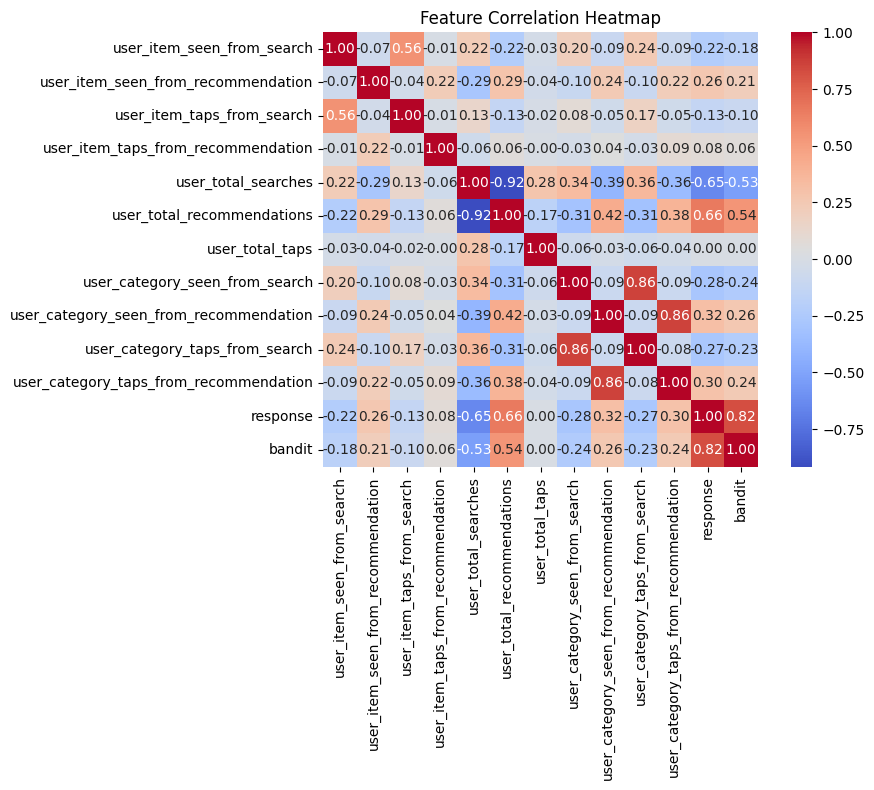

In [273]:
import  seaborn as sns
# === Корреляционная тепловая карта ===
plt.figure(figsize=(10, 8))
corr = test[TRAIN_FEATURES.tolist() + ['bandit']].corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", square=True)
plt.title("Feature Correlation Heatmap")
plt.tight_layout()
plt.show()